# Part 1d: Monte Carlo Dropout — TensorFlow & PyTorch

**Objective:** Use dropout at inference time to get uncertainty estimates. Instead of a single prediction, we run multiple forward passes with dropout enabled and analyze the distribution.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
print(f"TF: {tf.__version__}, PyTorch: {torch.__version__}")

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32")/255.0, X_test.astype("float32")/255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_train_flat, X_test_flat = X_train.reshape(len(X_train),-1), X_test.reshape(len(X_test),-1)
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

TF: 2.19.0, PyTorch: 2.10.0+cu128
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


## TensorFlow: MC Dropout
We build a model with `Dropout` layers, then at inference call the model with `training=True` to keep dropout active.

In [2]:
# Build and train TF model
class MCDropoutModel(keras.Model):
    """Model where dropout stays active during inference when training=True is passed."""
    def __init__(self):
        super().__init__()
        self.dense1 = layers.Dense(512, activation='relu')
        self.drop1 = layers.Dropout(0.3)
        self.dense2 = layers.Dense(256, activation='relu')
        self.drop2 = layers.Dropout(0.3)
        self.dense3 = layers.Dense(128, activation='relu')
        self.drop3 = layers.Dropout(0.3)
        self.output_layer = layers.Dense(10, activation='softmax')

    def call(self, inputs, training=False):
        x = self.drop1(self.dense1(inputs), training=training)
        x = self.drop2(self.dense2(x), training=training)
        x = self.drop3(self.dense3(x), training=training)
        return self.output_layer(x)

mc_model = MCDropoutModel()
mc_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mc_model.fit(X_train_flat, y_train, epochs=20, batch_size=256, validation_split=0.2, verbose=1)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.2102 - loss: 2.1170 - val_accuracy: 0.3055 - val_loss: 1.9299
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2883 - loss: 1.9399 - val_accuracy: 0.3272 - val_loss: 1.8793
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3140 - loss: 1.8843 - val_accuracy: 0.3502 - val_loss: 1.8087
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3246 - loss: 1.8520 - val_accuracy: 0.3659 - val_loss: 1.7936
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3356 - loss: 1.8123 - val_accuracy: 0.3800 - val_loss: 1.7497
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3450 - loss: 1.7954 - val_accuracy: 0.3875 - val_loss: 1.7180
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3516 - loss: 1.7794 - val_accuracy: 0.3962 - val_loss: 1.6972
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3623 - loss: 1.7559 - val_accuracy: 

In [3]:
# MC Dropout inference — run 100 forward passes with dropout enabled
n_samples = 100
sample_images = X_test_flat[:5]
sample_labels = y_test[:5]

# Collect predictions from multiple stochastic forward passes
mc_predictions = np.array([mc_model(sample_images, training=True).numpy() for _ in range(n_samples)])
# Shape: (100, 5, 10) — 100 passes, 5 images, 10 classes

# Mean prediction and standard deviation (uncertainty)
mean_preds = mc_predictions.mean(axis=0)   # (5, 10)
std_preds = mc_predictions.std(axis=0)      # (5, 10)

print("MC Dropout Predictions for 5 test samples:")
for i in range(5):
    pred_class = np.argmax(mean_preds[i])
    confidence = mean_preds[i][pred_class]
    uncertainty = std_preds[i][pred_class]
    actual = class_names[sample_labels[i]]
    print(f"  Image {i}: Predicted={class_names[pred_class]} (conf={confidence:.3f} ± {uncertainty:.3f}), Actual={actual}")

MC Dropout Predictions for 5 test samples:
  Image 0: Predicted=cat (conf=0.211 ± 0.063), Actual=cat
  Image 1: Predicted=truck (conf=0.329 ± 0.142), Actual=ship
  Image 2: Predicted=ship (conf=0.438 ± 0.146), Actual=ship
  Image 3: Predicted=ship (conf=0.323 ± 0.119), Actual=airplane
  Image 4: Predicted=deer (conf=0.389 ± 0.089), Actual=frog


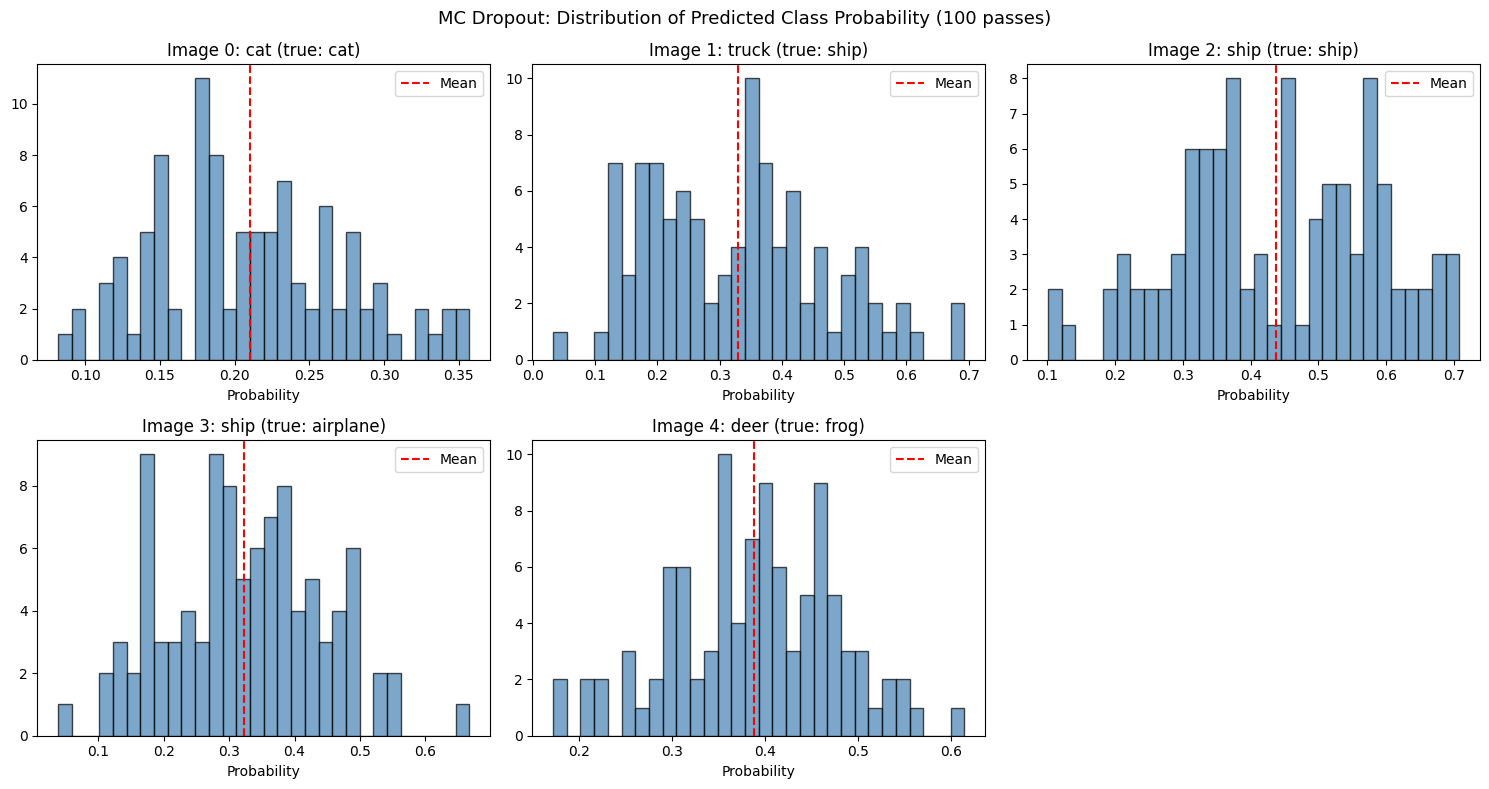

In [4]:
# Visualize uncertainty distribution for one image
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i in range(5):
    ax = axes[i//3][i%3]
    # Plot distribution of predicted class probabilities across MC samples
    pred_class = np.argmax(mean_preds[i])
    samples_for_pred = mc_predictions[:, i, pred_class]
    ax.hist(samples_for_pred, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(mean_preds[i][pred_class], color='red', linestyle='--', label='Mean')
    ax.set_title(f"Image {i}: {class_names[pred_class]} (true: {class_names[sample_labels[i]]})")
    ax.set_xlabel('Probability'); ax.legend()

axes[1][2].axis('off')
plt.suptitle('MC Dropout: Distribution of Predicted Class Probability (100 passes)', fontsize=13)
plt.tight_layout(); plt.show()

## PyTorch: MC Dropout
In PyTorch, we call `model.train()` before inference to keep dropout active, or use a custom module that ignores the training flag.

In [5]:
# PyTorch MC Dropout
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MCDropoutNetPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

# Train
pt_mc = MCDropoutNetPT().to(device)
opt = optim.Adam(pt_mc.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_flat), torch.LongTensor(y_train)),
                    batch_size=256, shuffle=True)

for epoch in range(20):
    pt_mc.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); crit(pt_mc(xb), yb).backward(); opt.step()
    if (epoch+1) % 5 == 0: print(f"Epoch {epoch+1}/20 done")

# MC Inference — keep model in TRAIN mode so dropout stays active
pt_mc.train()  # <-- KEY: don't call eval()!
sample_t = torch.FloatTensor(X_test_flat[:5]).to(device)

with torch.no_grad():
    pt_mc_preds = torch.stack([torch.softmax(pt_mc(sample_t), dim=1) for _ in range(100)])
    # Shape: (100, 5, 10)

pt_mean = pt_mc_preds.mean(0).cpu().numpy()
pt_std = pt_mc_preds.std(0).cpu().numpy()

print("\nPyTorch MC Dropout Predictions:")
for i in range(5):
    pred_class = np.argmax(pt_mean[i])
    print(f"  Image {i}: {class_names[pred_class]} (conf={pt_mean[i][pred_class]:.3f} ± {pt_std[i][pred_class]:.3f}), True={class_names[y_test[i]]}")

Epoch 5/20 done
Epoch 10/20 done
Epoch 15/20 done
Epoch 20/20 done

PyTorch MC Dropout Predictions:
  Image 0: cat (conf=0.281 ± 0.079), True=cat
  Image 1: truck (conf=0.398 ± 0.127), True=ship
  Image 2: ship (conf=0.505 ± 0.161), True=ship
  Image 3: ship (conf=0.378 ± 0.136), True=airplane
  Image 4: deer (conf=0.401 ± 0.110), True=frog


## Key Takeaways
- **MC Dropout** = run inference multiple times with dropout ON → get uncertainty
- High std deviation = model is uncertain → useful for safety-critical applications
- Applications: medical diagnosis, autonomous driving, active learning
- In TensorFlow: pass `training=True` during inference
- In PyTorch: keep `model.train()` or create an "always-on" dropout layer
- Typically 50-100 forward passes gives stable uncertainty estimates